In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, accuracy_score

# %%
# 2. 載入資料
# 請將 raw_data.csv 放在當前工作目錄
df = pd.read_csv('./raw_data/raw_data.csv')

# 檢視前幾筆資料
print(df.head())

   Second_Stroke  age  sex  HLOS  NIHSS  tPA(0/1)  EVT(0/1)  HTN(0/1)  \
0              0   71    1    12      5         0         0         0   
1              0   65    1    14      9         0         0         0   
2              0   62    1    13      2         0         0         1   
3              0   91    1    18     32         0         0         1   
4              0   68    0    41     18         0         0         1   

   DM(0/1)  Dyslipidemia(0/1)  Af(0/1)  smoking(Y/N/Q)   LDL   cholesterol  \
0        0                  0        0               0   81.7          180   
1        0                  1        0               0  116.5          235   
2        0                  1        0               0  116.3          187   
3        1                  0        0               0   78.2          127   
4        1                  1        0               2  109.0          173   

    TG   Cre  SGPT  HbA1c  MRS  
0   57  0.35  80.0    5.1    4  
1  155  0.37  87.0    4.6 

In [28]:
print(f"資料維度: {df.shape}")
print(df.info())

資料維度: (1484, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1484 entries, 0 to 1483
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Second_Stroke      1484 non-null   int64  
 1   age                1484 non-null   int64  
 2   sex                1484 non-null   int64  
 3   HLOS               1484 non-null   int64  
 4   NIHSS              1484 non-null   int64  
 5   tPA(0/1)           1484 non-null   int64  
 6   EVT(0/1)           1484 non-null   int64  
 7   HTN(0/1)           1484 non-null   int64  
 8   DM(0/1)            1484 non-null   int64  
 9   Dyslipidemia(0/1)  1484 non-null   int64  
 10  Af(0/1)            1484 non-null   int64  
 11  smoking(Y/N/Q)     1484 non-null   int64  
 12  LDL                1484 non-null   float64
 13  cholesterol        1484 non-null   int64  
 14  TG                 1484 non-null   int64  
 15  Cre                1484 non-null   float64
 16  SGPT   

In [29]:
# 3.1 缺失值檢查
missing = df.isnull().sum()
print(missing[missing > 0])

Series([], dtype: int64)


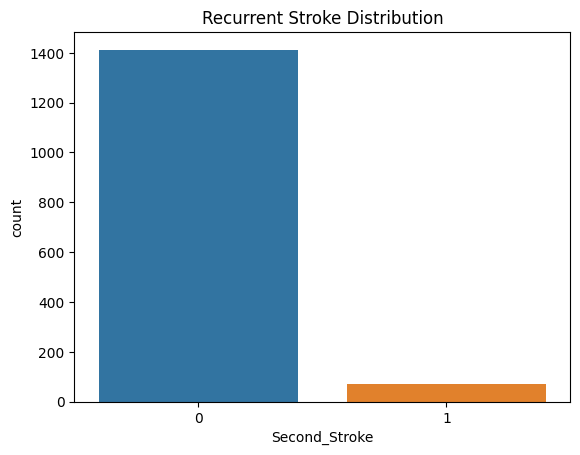

In [30]:
# 3.2 目標變數分布 (假設目標欄位為 'recurrent_stroke')
sns.countplot(data=df, x='Second_Stroke')
plt.title('Recurrent Stroke Distribution')
plt.show()

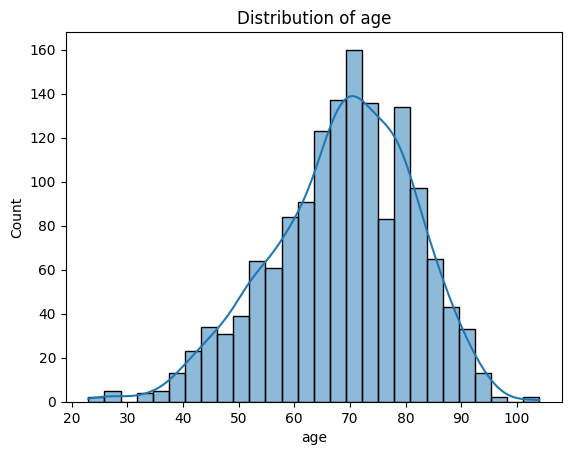

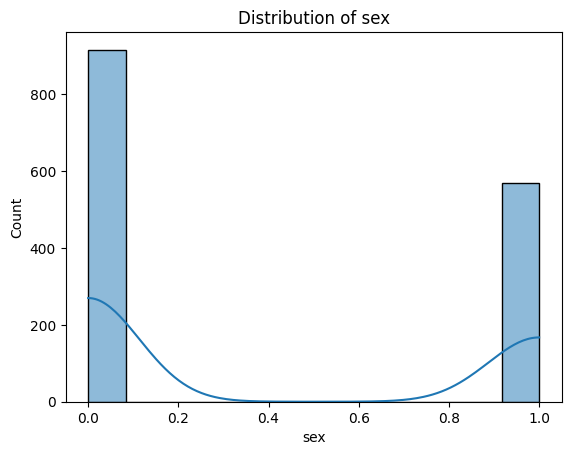

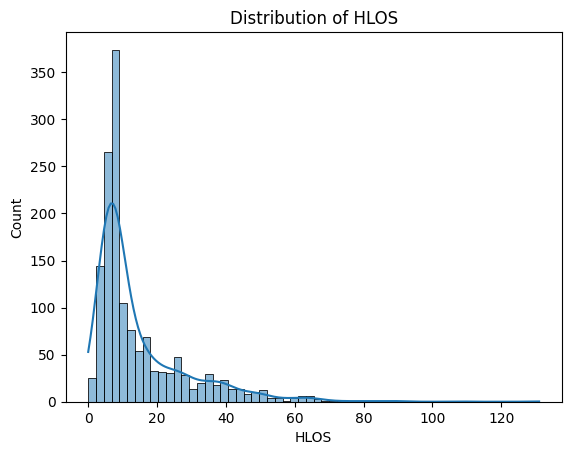

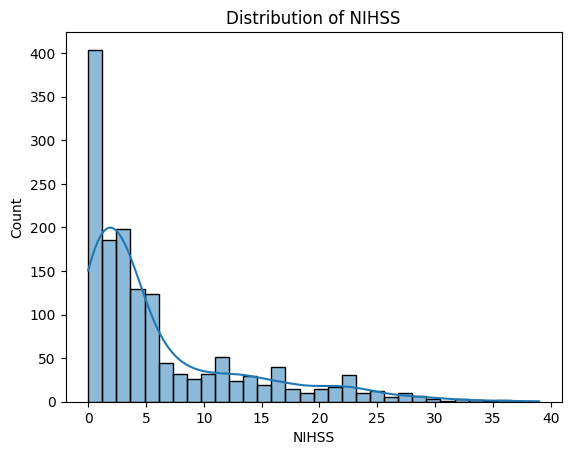

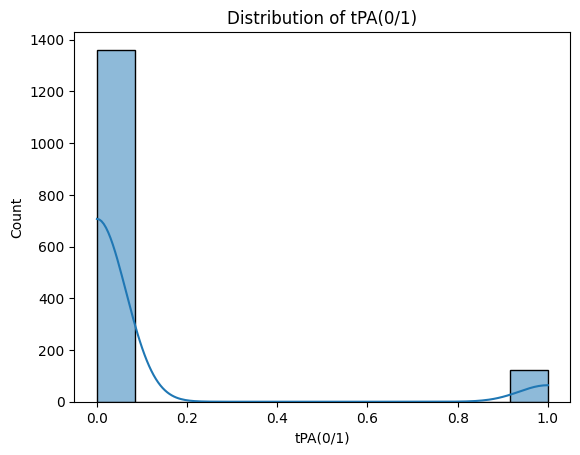

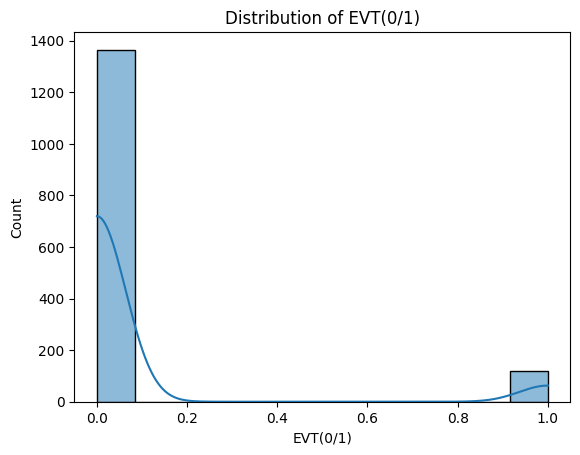

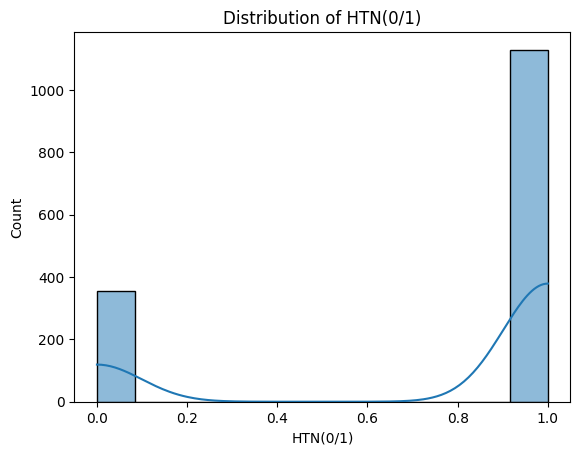

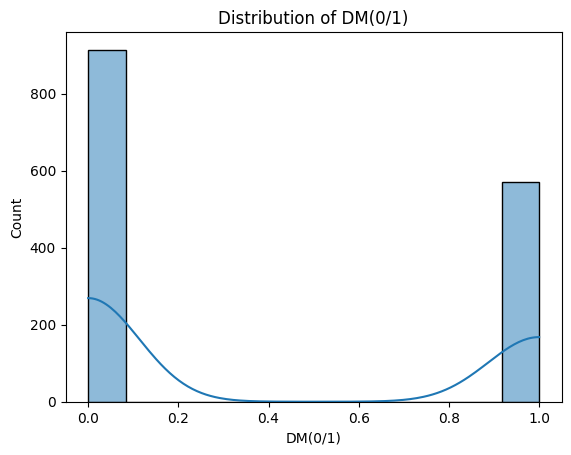

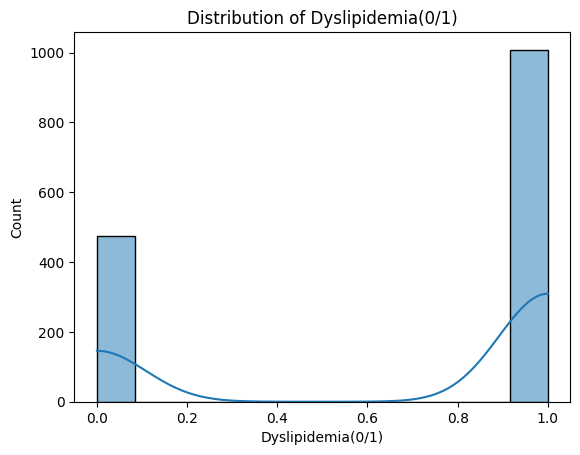

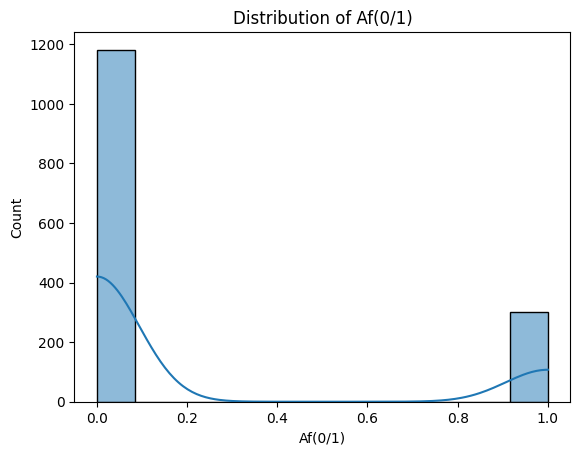

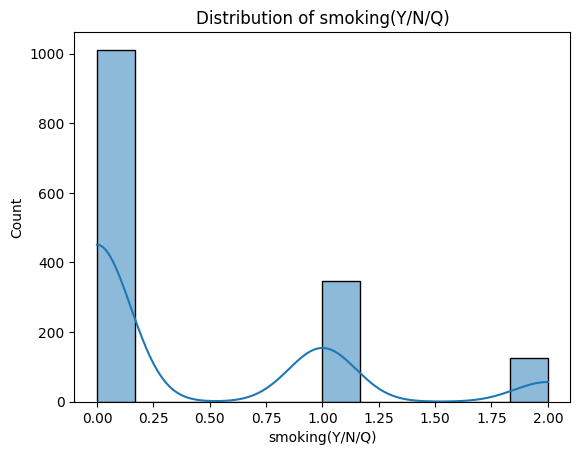

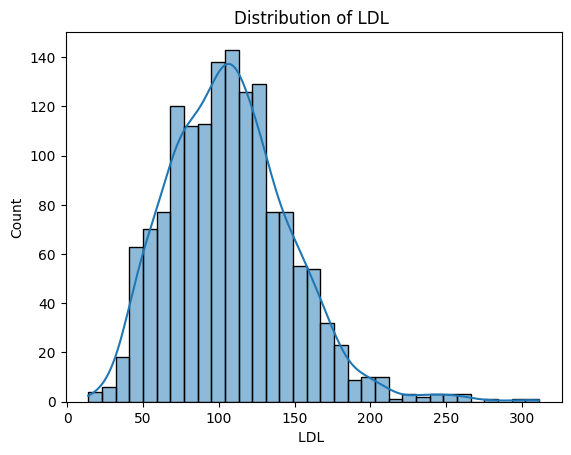

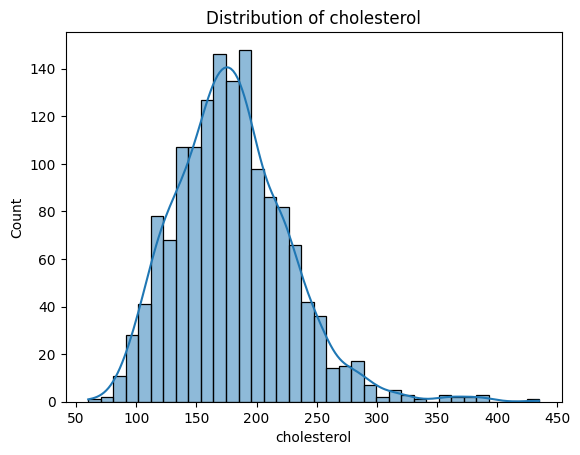

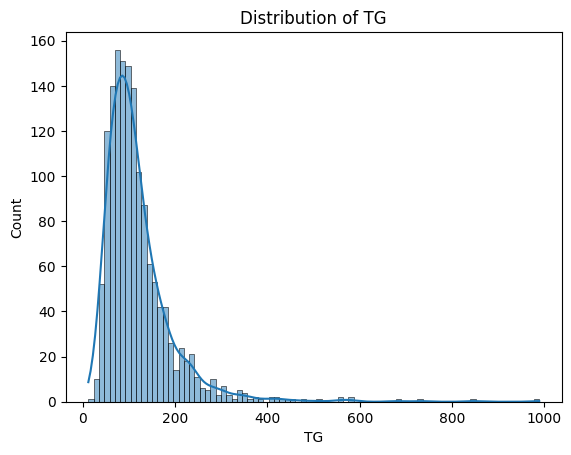

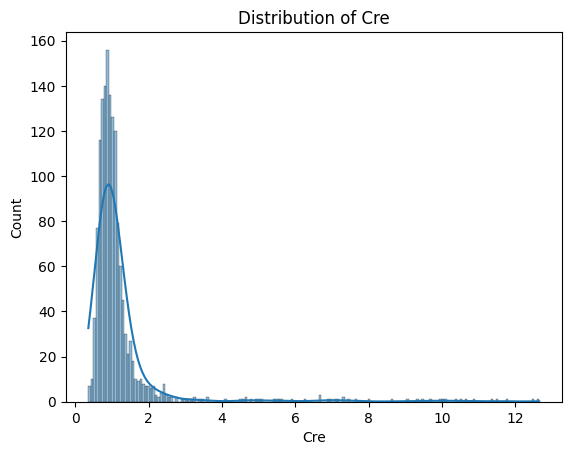

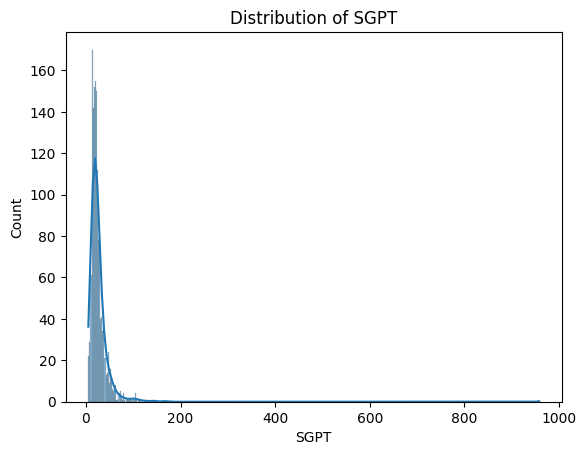

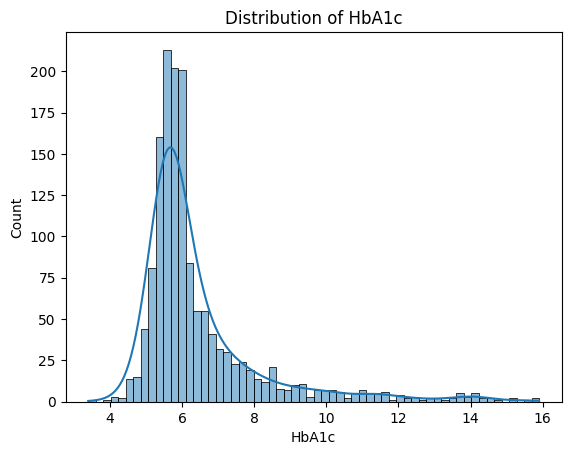

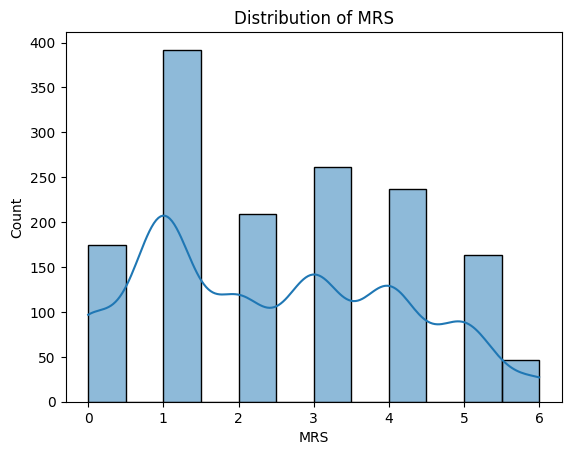

In [31]:
# 3.3 數值特徵分布
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('Second_Stroke')
for col in num_cols:
    plt.figure()
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

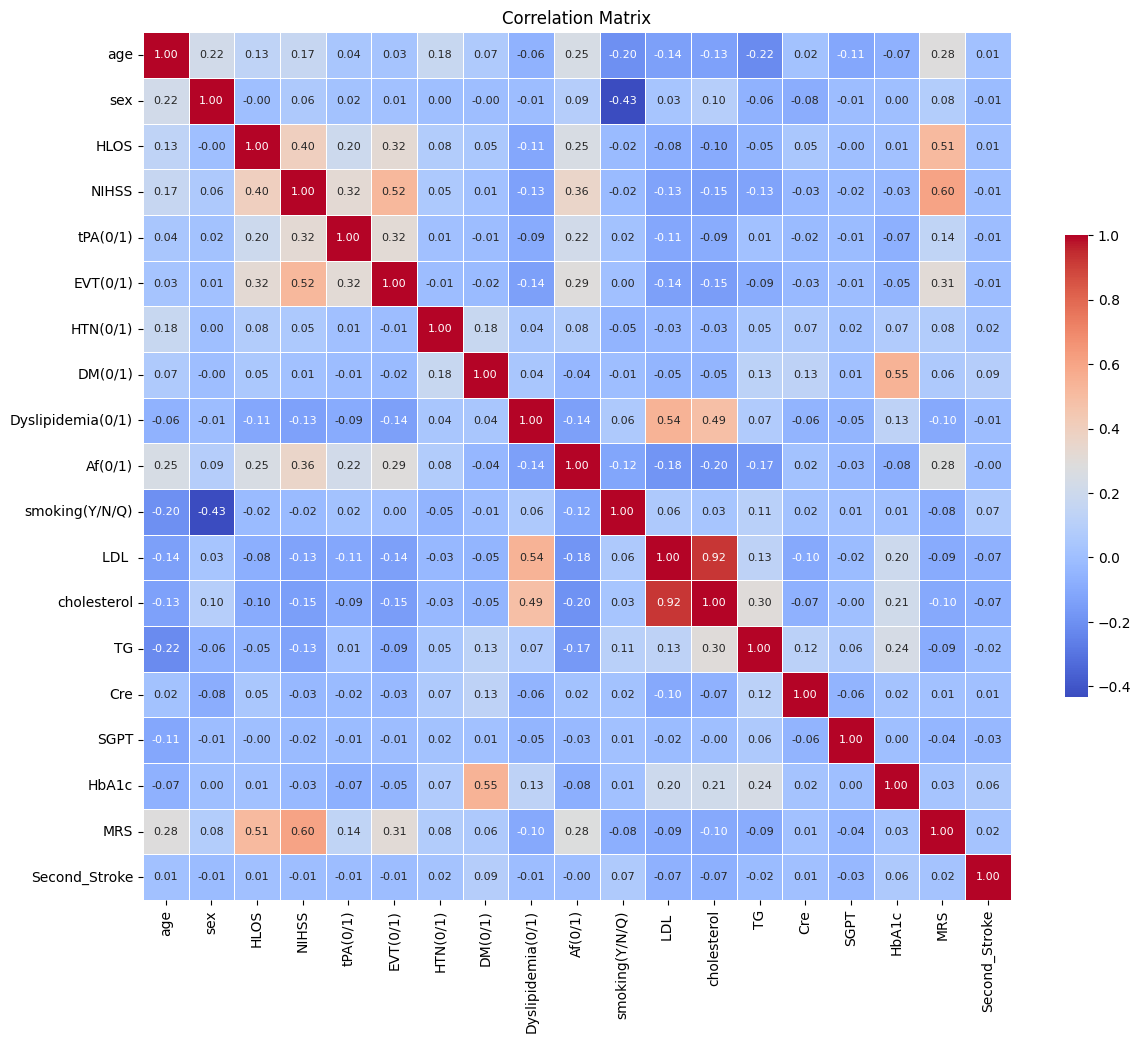

In [32]:
# 3.4 數值特徵相關性熱圖
corr = df[num_cols.tolist() + ['Second_Stroke']].corr()
# 1. 增大画布，2. 缩小整体字体
plt.figure(figsize=(14, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',square=True,                 # 更好地保持单元格为正方形
    linewidths=0.5,              # 单元格边框
    cbar_kws={'shrink': 0.5},    # 颜色条缩小
    annot_kws={'size': 8}  )
plt.title('Correlation Matrix')
plt.show()

In [33]:
labels = ['female', 'male']
df['sex_group'] = df['sex'].map({0: 'male', 1: 'female'})
print(df[['sex','sex_group','Second_Stroke']].head())

   sex sex_group  Second_Stroke
0    1    female              0
1    1    female              0
2    1    female              0
3    1    female              0
4    0      male              0


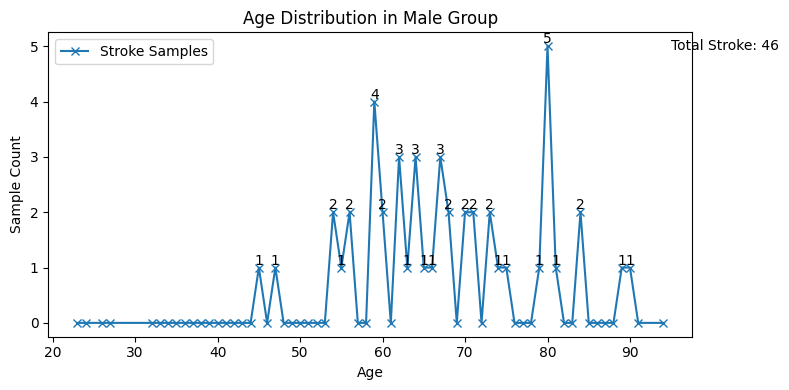

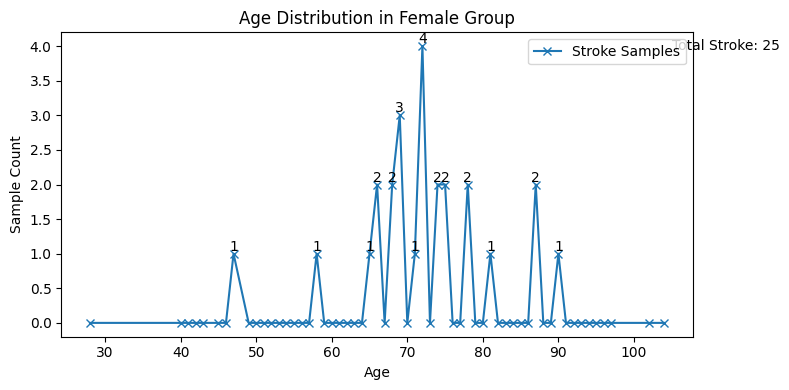

In [34]:
# 如果还没创建 sex_group，可先这样做：
# df['sex_group'] = df['sex'].map({0: 'male', 1: 'female'})

for sex in ['male', 'female']:
    grp = df[df['sex_group'] == sex]
    
    # 每年龄的 stroke 样本计数
    stroke_counts = grp[grp['Second_Stroke'] == 1]['age'].value_counts().sort_index()
    ages = sorted(grp['age'].unique())
    stroke = stroke_counts.reindex(ages, fill_value=0)
    
    # 画图
    plt.figure(figsize=(8,4))
    plt.plot(ages, stroke.values, marker='x', label='Stroke Samples')
    
    # 在每个点上标注数值
    for x, y in zip(ages, stroke.values):
        if y > 0:
            plt.text(x, y, str(int(y)), ha='center', va='bottom')
    
    # 标注该性别的中风总数
    total_strokes = int(stroke.sum())
    last_age = ages[-1]
    plt.text(last_age + 1, max(stroke.values), f'Total Stroke: {total_strokes}', 
             ha='left', va='center')
    
    plt.xlabel('Age')
    plt.ylabel('Sample Count')
    plt.title(f'Age Distribution in {sex.capitalize()} Group')
    plt.legend()
    plt.tight_layout()
    plt.show()


# Sex:F/M 資料準備

In [35]:
# 我們先過濾出 young 組
young_df = df[df['sex_group'] == 'female']

# 準備特徵矩陣 X 和標籤 y
X_young = young_df.drop(columns=['Second_Stroke', 'sex_group'])
y_young = young_df['Second_Stroke']

#### 3. 區分連續與離散欄位

In [36]:
cat_cols = ['sex','tPA(0/1)','EVT(0/1)','HTN(0/1)', 
            'DM(0/1)','Dyslipidemia(0/1)','Af(0/1)','smoking(Y/N/Q)', 'MRS']
num_cols = [c for c in X_young.columns 
            if c not in cat_cols]
print(f"所有特徵: {X_young.columns.tolist()}")
print(f"類別特徵: {cat_cols}")
print(f"數值特徵: {num_cols}")

所有特徵: ['age', 'sex', 'HLOS', 'NIHSS', 'tPA(0/1)', 'EVT(0/1)', 'HTN(0/1)', 'DM(0/1)', 'Dyslipidemia(0/1)', 'Af(0/1)', 'smoking(Y/N/Q)', 'LDL ', 'cholesterol', 'TG', 'Cre', 'SGPT', 'HbA1c', 'MRS']
類別特徵: ['sex', 'tPA(0/1)', 'EVT(0/1)', 'HTN(0/1)', 'DM(0/1)', 'Dyslipidemia(0/1)', 'Af(0/1)', 'smoking(Y/N/Q)', 'MRS']
數值特徵: ['age', 'HLOS', 'NIHSS', 'LDL ', 'cholesterol', 'TG', 'Cre', 'SGPT', 'HbA1c']


### 3. 建前處理器

In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from imblearn.pipeline import Pipeline

num_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler())
])
cat_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore', sparse=False))
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

### SMOTENC 需要將離散特徵轉為 onehot-code / 準備 stroke samples

In [38]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTENC

# —— 1. 拆分正负样本（保持为 DataFrame/Series）
idx_pos = young_df[young_df['Second_Stroke']==1].index
idx_neg = young_df[young_df['Second_Stroke']==0].index

X_pos_df = young_df.loc[idx_pos].drop(columns=['Second_Stroke','sex_group'])
y_pos_ser = young_df.loc[idx_pos, 'Second_Stroke']

X_neg_df = young_df.loc[idx_neg].drop(columns=['Second_Stroke','sex_group'])
y_neg_ser = young_df.loc[idx_neg, 'Second_Stroke']

# —— 2. Fit 整体 preprocessor
preprocessor.fit(X_young)

# —— 3. Transform（传入 DataFrame）
X_pos_arr = preprocessor.transform(X_pos_df)  # numpy array 输出
X_neg_arr = preprocessor.transform(X_neg_df)

all_feats = preprocessor.get_feature_names_out()

# 4. 找出哪幾個欄位是 one-hot 出來的 categorical（以 'cat__' 開頭為例）
cat_indices = [
    i for i, f in enumerate(all_feats)
    if f.startswith('cat__')
]

# —— 4. 把标签取成 numpy
y_pos = y_pos_ser.values
y_neg = y_neg_ser.values

# —— 5. 合并，准备做 SMOTE（以正样本补到 50 为例）
X_train = np.vstack([X_pos_arr, X_neg_arr])
y_train = np.concatenate([y_neg, y_pos])

sm = SMOTENC(
    categorical_features=cat_indices,
    sampling_strategy={1: 50},
    random_state=42
)

X_res, y_res = sm.fit_resample(X_train, y_train)

# —— 6. 从过采样结果里提取正样本，直接替换 X_pos_pre / y_pos
mask_pos = (y_res == 1)
X_pos = X_res[mask_pos]
y_pos     = y_res[mask_pos]

print(f"SMOTE 后的正样本：X_pos_pre shape = {X_pos.shape}, y_pos shape = {y_pos.shape}")
# —— 6. 从过采样结果里提取正样本
mask_pos = (y_res == 1)
X_pos = X_res[mask_pos]
y_pos = y_res[mask_pos]

# 把 X_pos 转成 DataFrame，columns 用 all_feats
df_pos = pd.DataFrame(X_pos, columns=all_feats)

# 印出前五筆 X 與對應的 y
print("\n前五筆樣本 (X)：")
print(df_pos.head())

print("\n前五筆樣本對應的 y：")
print(y_pos[:5])


SMOTE 后的正样本：X_pos_pre shape = (50, 32), y_pos shape = (50,)

前五筆樣本 (X)：
   num__age  num__HLOS  num__NIHSS  num__LDL   num__cholesterol   num__TG  \
0  0.552303   0.229044   -0.345834  -1.445836         -1.273406 -0.995965   
1  0.390096   1.867728    1.605494   0.346593         -0.271531 -0.436995   
2  1.525544   1.582740    1.865671  -1.452810         -1.902033 -0.754248   
3 -1.313076  -0.554674   -0.736100  -0.729794         -0.409043  2.478715   
4  0.552303  -0.625921   -0.866188  -1.255201         -1.116249  0.167297   

   num__Cre  num__SGPT  num__HbA1c  cat__sex_1  ...  cat__smoking(Y/N/Q)_0  \
0  1.122178  -0.203644   -0.382130         1.0  ...                    1.0   
1  1.194719  -0.390057   -0.610603         1.0  ...                    1.0   
2  1.218900  -0.250247    0.074817         1.0  ...                    1.0   
3  1.355923   0.239089   -0.325011         1.0  ...                    0.0   
4  1.742810  -0.226945   -0.039420         1.0  ...                    1.0 

/usr/local/lib/python3.8/site-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


### 將 normal data 切割成十份

In [39]:
import numpy as np

# 假设你已经有：
# X_neg_pre: numpy array, shape (N_neg, n_features)
# y_neg_arr: numpy array, shape (N_neg,)

rng = np.random.RandomState(42)

# 1. 用整数索引打乱
neg_idx = np.arange(len(X_neg_arr))        # [0, 1, 2, …, N_neg-1]
shuffled_idx = rng.permutation(neg_idx)

# 2. 平均拆成 10 份
fold_indices = np.array_split(shuffled_idx, 10)

# 3. 切出每一份
X_neg_folds = [X_neg_arr[idx] for idx in fold_indices]
y_neg_folds = [y_neg[idx]   for idx in fold_indices]

# 4. 检查形状
for i, (Xf, yf) in enumerate(zip(X_neg_folds, y_neg_folds), start=1):
    print(f"Fold {i:2d}: X_neg.shape = {Xf.shape}, y_neg.shape = {yf.shape}")


Fold  1: X_neg.shape = (55, 32), y_neg.shape = (55,)
Fold  2: X_neg.shape = (55, 32), y_neg.shape = (55,)
Fold  3: X_neg.shape = (55, 32), y_neg.shape = (55,)
Fold  4: X_neg.shape = (54, 32), y_neg.shape = (54,)
Fold  5: X_neg.shape = (54, 32), y_neg.shape = (54,)
Fold  6: X_neg.shape = (54, 32), y_neg.shape = (54,)
Fold  7: X_neg.shape = (54, 32), y_neg.shape = (54,)
Fold  8: X_neg.shape = (54, 32), y_neg.shape = (54,)
Fold  9: X_neg.shape = (54, 32), y_neg.shape = (54,)
Fold 10: X_neg.shape = (54, 32), y_neg.shape = (54,)


In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

models = []
fold_stats = []

for i in range(10):
    # 1. 取出第 i 折的负样本
    X_neg_i, y_neg_i = X_neg_folds[i], y_neg_folds[i]
    
    # 2. 合并负样本 + 正样本
    X_comb = np.vstack([X_neg_i, X_pos])
    y_comb = np.concatenate([y_neg_i, y_pos])
    
    # 3. 切 80% 训练 / 20% 验证, 保持类别比例
    X_train_i, X_val_i, y_train_i, y_val_i = train_test_split(
        X_comb, y_comb,
        train_size=0.8,
        random_state=42,
        stratify=y_comb
    )
    
    # 4. 训练模型
    rf = RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42
    )
    rf.fit(X_train_i, y_train_i)
    
    # 5. 在验证集上预测并计算指标
    y_pred  = rf.predict(X_val_i)
    y_proba = rf.predict_proba(X_val_i)[:, 1]
    
    prec = precision_score(y_val_i, y_pred, zero_division=0)
    rec  = recall_score   (y_val_i, y_pred, zero_division=0)
    f1   = f1_score       (y_val_i, y_pred, zero_division=0)
    auc  = roc_auc_score  (y_val_i, y_proba)
    
    # 6. 打印结果并保存
    n_train = len(y_train_i)
    n_val   = len(y_val_i)
    print(
        f"Fold {i+1:2d} ｜ Train={n_train} (0={np.sum(y_train_i==0)},1={np.sum(y_train_i==1)})  "
        f"Val={n_val} (0={np.sum(y_val_i==0)},1={np.sum(y_val_i==1)})\n"
        f"       Precision={prec:.3f}, Recall={rec:.3f}, F1={f1:.3f}, AUC={auc:.3f}\n"
    )


    # 假设 fold_stats 是一个包含 (precision, recall, f1, auc) 的列表
    # e.g. fold_stats = [(prec1, rec1, f11, auc1), (prec2, rec2, f12, auc2), …]
    
    models.append(rf)
    fold_stats.append((prec, rec, f1, auc))

# fold_stats 列表中存了 10 折的 (precision, recall, f1, auc)


Fold  1 ｜ Train=84 (0=44,1=40)  Val=21 (0=11,1=10)
       Precision=0.889, Recall=0.800, F1=0.842, AUC=0.964

Fold  2 ｜ Train=84 (0=44,1=40)  Val=21 (0=11,1=10)
       Precision=0.909, Recall=1.000, F1=0.952, AUC=0.927

Fold  3 ｜ Train=84 (0=44,1=40)  Val=21 (0=11,1=10)
       Precision=1.000, Recall=0.900, F1=0.947, AUC=1.000

Fold  4 ｜ Train=83 (0=43,1=40)  Val=21 (0=11,1=10)
       Precision=1.000, Recall=0.900, F1=0.947, AUC=1.000

Fold  5 ｜ Train=83 (0=43,1=40)  Val=21 (0=11,1=10)
       Precision=1.000, Recall=0.900, F1=0.947, AUC=0.991

Fold  6 ｜ Train=83 (0=43,1=40)  Val=21 (0=11,1=10)
       Precision=1.000, Recall=1.000, F1=1.000, AUC=1.000

Fold  7 ｜ Train=83 (0=43,1=40)  Val=21 (0=11,1=10)
       Precision=0.900, Recall=0.900, F1=0.900, AUC=0.909

Fold  8 ｜ Train=83 (0=43,1=40)  Val=21 (0=11,1=10)
       Precision=1.000, Recall=0.900, F1=0.947, AUC=0.945

Fold  9 ｜ Train=83 (0=43,1=40)  Val=21 (0=11,1=10)
       Precision=1.000, Recall=0.800, F1=0.889, AUC=0.968

Fold 10 ｜ 

In [41]:
precisions, recalls, f1s, aucs = zip(*fold_stats)

print(f"Average Precision: {np.mean(precisions):.3f}")
print(f"Average Recall   : {np.mean(recalls):.3f}")
print(f"Average F1-score : {np.mean(f1s):.3f}")
print(f"Average AUC      : {np.mean(aucs):.3f}")


Average Precision: 0.952
Average Recall   : 0.900
Average F1-score : 0.923
Average AUC      : 0.953
